In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix, classification_report

import torch
import random
import numpy as np

from src.preprocessing.precomputed import PrecomputedDataset
from src.models.crnn import CRNN
from src.utils import set_seed, evaluate
from src.preprocessing.dataset import (
    list_ravdess_files, 
    filter_audio_speech, 
    parse_ravdess_filename, 
    extract_label_idx, 
    IDX2LABEL
)

In [ ]:
# Config
set_seed(42)
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
N_FOLDS = 6
EPOCHS = 80
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# %%
# ======================
# DATASET
# ======================
# 1. Recupera lista attori e file originali per creare lo split 

# %%
# Se sei in train_precomputed.ipynb (nella root del progetto)
DATA_ROOT = "./data" 
# La cartella dei pre-calcolati è dentro scripts/
PRECOMPUTED_DIR = "./scripts/data_precomputed" 

# Verifica immediata
all_files = filter_audio_speech(list_ravdess_files(DATA_ROOT))
print(f"File audio trovati: {len(all_files)}") 

if len(all_files) == 0:
    # Se fallisce ancora, prova il percorso assoluto per debug
    print("DEBUG - Percorso assoluto data:", os.path.abspath(DATA_ROOT))

labels = [extract_label_idx(f) for f in all_files]
actors = [parse_ravdess_filename(f)["actor"] for f in all_files]

gkf = GroupKFold(n_splits=N_FOLDS)
fold_results = []

File audio trovati: 1440


In [ ]:
#FATTO MANUALMENTE PER AVERE LA STESSA CONFIGURAZIONE DEGLI ATTORI IN OGNI FOLD DELL'ESPERIMENTO 4

FOLDS = {
    0: {
        "test": ['06', '12', '18', '24'],
        "val":  ['15', '16']
    },
    1: {
        "test": ['07', '13', '19', '23'],
        "val":  ['04', '21']
    },
    2: {
        "test": ['02', '08', '14', '20'],
        "val":  ['07', '22']
    },
    3: {
        "test": ['03', '09', '15', '21'],
        "val":  ['12', '13']
    },
    4: {
        "test": ['04', '10', '16', '22'],
        "val":  ['08', '21']
    },
    5: {
        "test": ['01', '05', '11', '17'],
        "val":  ['09', '16']
    }
}


In [5]:
# %%
# Inizio Loop Cross-Validation


for fold_idx, (train_val_idx, test_idx) in enumerate(gkf.split(all_files, labels, groups=actors)):
    print(f"\n{'='*20} FOLD {fold_idx+1}/{N_FOLDS} {'='*20}")
    
    # =====================================================
    # A) SPLIT DEI FILE (IDENTICO AL PRIMO CODICE)
    # =====================================================

    fold = FOLDS[fold_idx]

    test_actors = fold["test"]
    val_actors = fold["val"]

    all_actors = sorted(set(actors))
    train_actors = [
        a for a in all_actors
        if a not in test_actors and a not in val_actors
    ]

    train_files = [
        f for f, a in zip(all_files, actors)
        if a in train_actors
    ]

    val_files = [
        f for f, a in zip(all_files, actors)
        if a in val_actors
    ]

    test_files = [
        f for f, a in zip(all_files, actors)
        if a in test_actors
    ]


    print(f"Train: {len(train_files)} files, {len(train_actors)} speakers {sorted(train_actors)}")
    print(f"Val:   {len(val_files)} files, {len(val_actors)} speakers {sorted(val_actors)}")
    print(f"Test:  {len(test_files)} files, {len(test_actors)} speakers {test_actors}")


    # Inizializzazione Dataset Pre-calcolati (filtrano internamente per attore)
    train_ds = PrecomputedDataset(PRECOMPUTED_DIR, train_actors)
    val_ds = PrecomputedDataset(PRECOMPUTED_DIR, val_actors)
    test_ds = PrecomputedDataset(PRECOMPUTED_DIR, test_actors)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # 3. CALCOLO WEIGHTS (Bilanciamento classi specifico per il set di train del fold)
    train_labels_fold = [y.item() for _, y in train_ds]
    counts = Counter(train_labels_fold)
    weights = torch.tensor(
        [1.0 / (counts[i] if counts[i] > 0 else 1) for i in range(8)], 
        dtype=torch.float, device=device
    )
    weights = weights / weights.sum() * 8

    # Inizializzazione Modello
    model = CRNN(n_classes=8, n_mels=64).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=6
    )

    best_val_acc = 0.0
    val_acc_hist = []
    test_acc_hist = []
    best_path = f"best_fold_{fold_idx+1}.pt"

    # ======================
    # TRAIN LOOP
    # ======================
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = torch.nn.functional.cross_entropy(
                logits, y, weight=weights, label_smoothing=0.1
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            running_loss += loss.item() * y.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total

        # Valutazione
        val_loss, val_acc = evaluate(model, val_loader, device)
        _, test_acc = evaluate(model, test_loader, device)

        scheduler.step(val_acc)
        val_acc_hist.append(val_acc)
        test_acc_hist.append(test_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:2d}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} | "
                  f"val acc {val_acc:.4f} | test acc {test_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)

    # =====================================================
    # G) VALUTAZIONE FINALE DEL FOLD
    # =====================================================
    model.load_state_dict(torch.load(best_path, map_location=device))
    final_test_loss, final_test_acc = evaluate(model, test_loader, device)
    
    print(f"\nRISULTATI FOLD {fold_idx + 1}: Best Val Acc {best_val_acc:.4f} | Final Test Acc {final_test_acc:.4f}")
    
    # Raccolta predizioni per report finale
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            logits = model(x)
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())
            y_true.extend(y.numpy().tolist())
    
    # H) SALVA RISULTATI
    fold_results.append({
        'fold': fold_idx,
        'test_speakers': test_actors,
        'val_speakers': sorted(val_actors),
        'train_speakers': sorted(train_actors),
        'best_val_acc': best_val_acc,
        'final_test_acc': final_test_acc,
        'val_acc_history': val_acc_hist,
        'test_acc_history': test_acc_hist,
        'y_true': y_true,
        'y_pred': y_pred
    })

# %%
# ANALISI FINALE AGGREGATA
print(f"\n{'='*70}\nRISULTATI FINALI CROSS-VALIDATION\n{'='*70}")
test_accs = [r['final_test_acc'] for r in fold_results]
val_accs = [r['best_val_acc'] for r in fold_results]

print(f"Validation Acc Media: {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"Test Acc Media:       {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")

# %%
# Visualizzazioni (Grafici Accuratezza)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, r in enumerate(fold_results):
    ax = axes[idx]
    ax.plot(r['val_acc_history'], label='Val')
    ax.plot(r['test_acc_history'], label='Test')
    ax.set_title(f"Fold {idx+1}")
    ax.legend()
plt.tight_layout()
plt.show()


==================== FOLD 1/6 ====================
Train: 1080 files, 18 speakers ['01', '02', '03', '04', '05', '07', '08', '09', '10', '11', '13', '14', '17', '19', '20', '21', '22', '23']
Val:   120 files, 2 speakers ['15', '16']
Test:  240 files, 4 speakers ['06', '12', '18', '24']
Epoch  1/10 | train loss 2.0207 acc 0.2030 | val acc 0.3583 | test acc 0.3302
Epoch 10/10 | train loss 1.0175 acc 0.7657 | val acc 0.6062 | test acc 0.6365

RISULTATI FOLD 1: Best Val Acc 0.6208 | Final Test Acc 0.6281

==================== FOLD 2/6 ====================
Train: 1080 files, 18 speakers ['01', '02', '03', '05', '06', '08', '09', '10', '11', '12', '14', '15', '16', '17', '18', '20', '22', '24']
Val:   120 files, 2 speakers ['04', '21']
Test:  240 files, 4 speakers ['07', '13', '19', '23']
Epoch  1/10 | train loss 1.9499 acc 0.2472 | val acc 0.3500 | test acc 0.2781
Epoch 10/10 | train loss 0.9659 acc 0.7942 | val acc 0.5958 | test acc 0.5104

RISULTATI FOLD 2: Best Val Acc 0.5958 | Final Te

KeyboardInterrupt: 


RISULTATI FINALI CROSS-VALIDATION (6 FOLDS)

Risultati per fold:
Fold   Val Acc    Test Acc   Test Speakers
----------------------------------------------------------------------
1      0.6208     0.6281     ['06', '12', '18', '24']
2      0.4625     0.4437     ['05', '11', '17', '23']
3      0.5813     0.6208     ['04', '10', '16', '22']
4      0.5979     0.5021     ['03', '09', '15', '21']
5      0.5104     0.7000     ['02', '08', '14', '20']
6      0.6167     0.5406     ['01', '07', '13', '19']

MEDIA ± STD:
  Validation Acc: 0.5649 ± 0.0586
  Test Acc:       0.5726 ± 0.0859


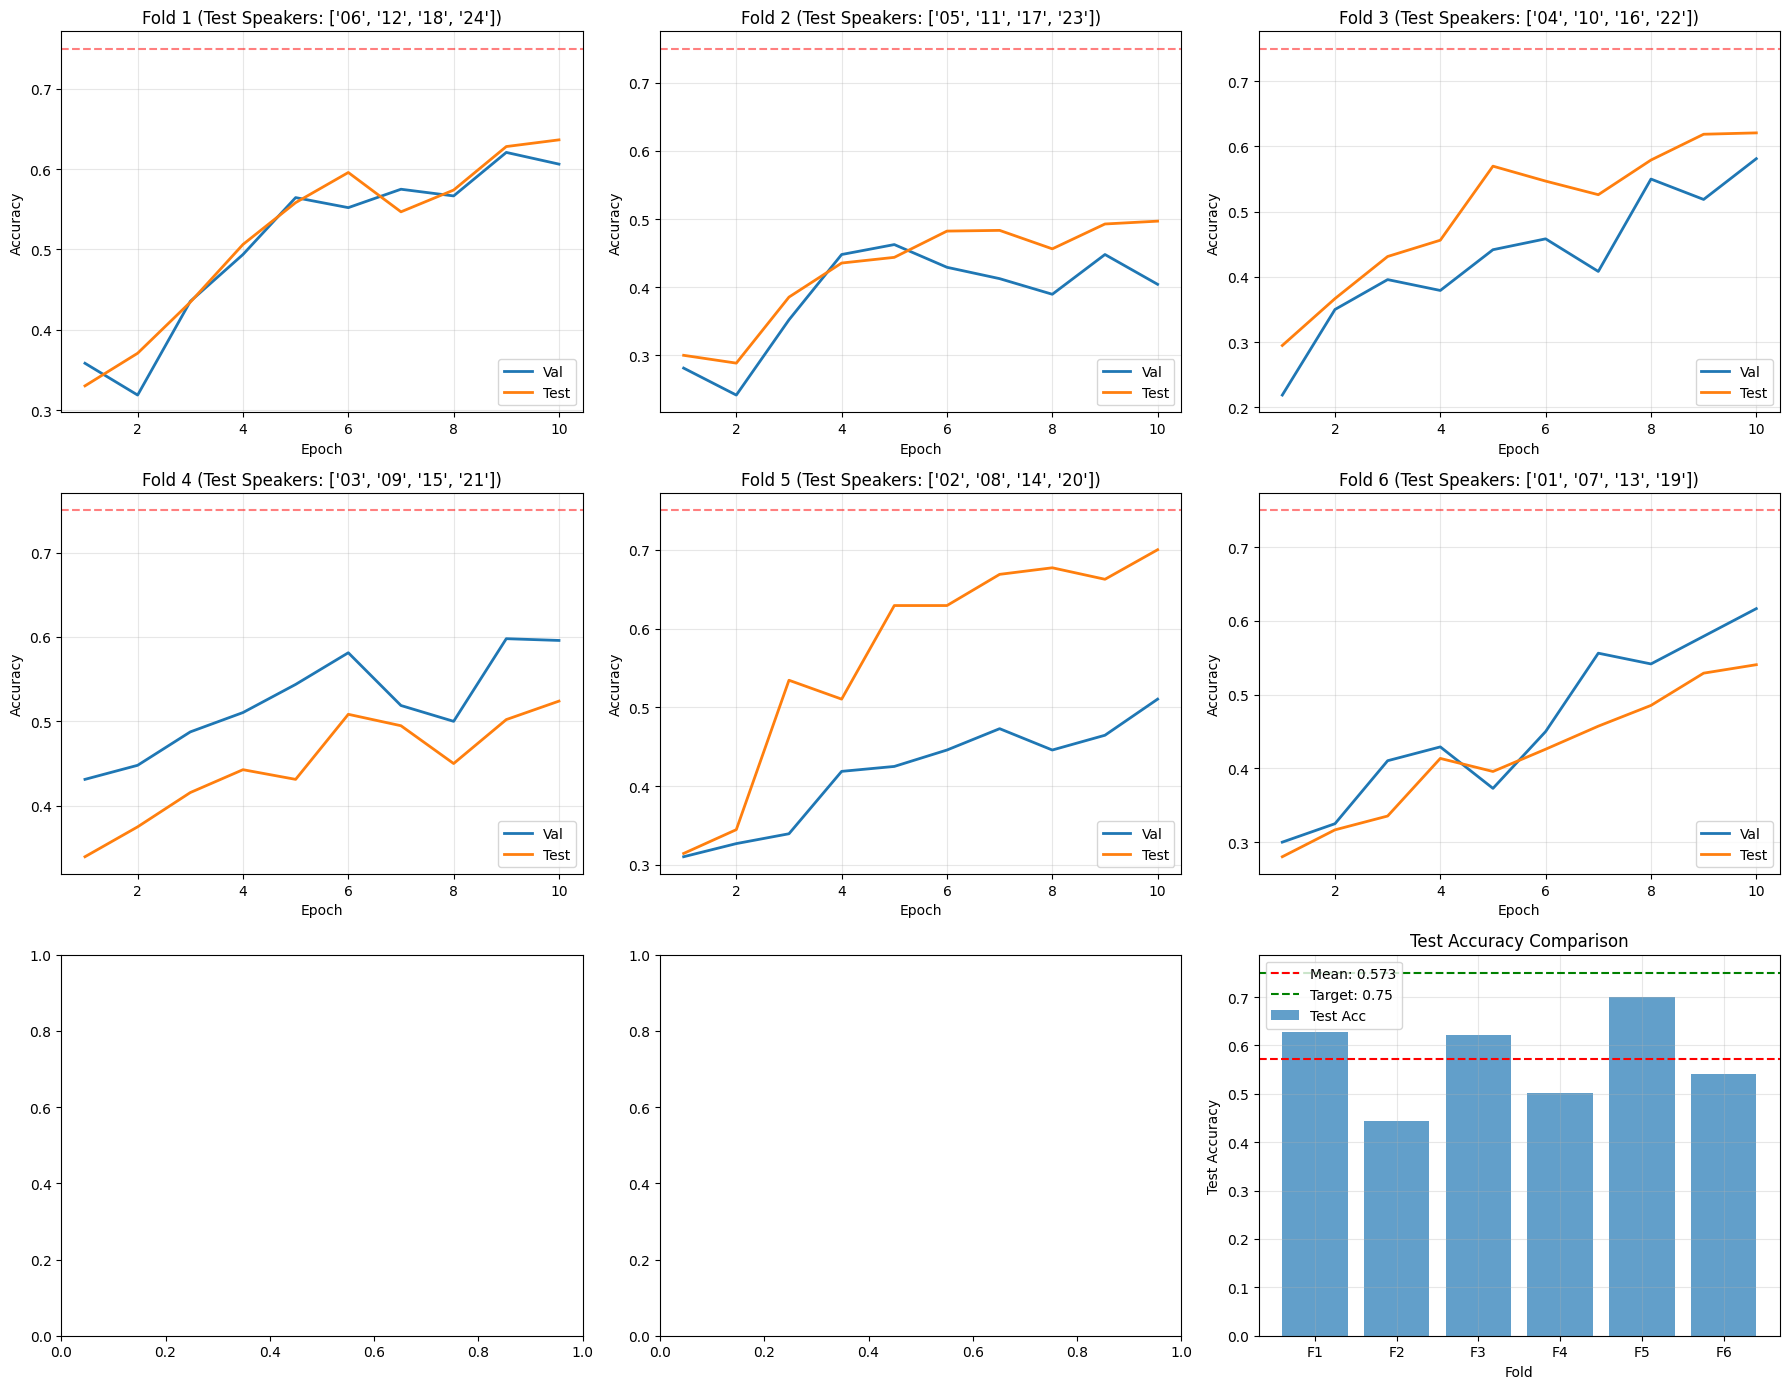

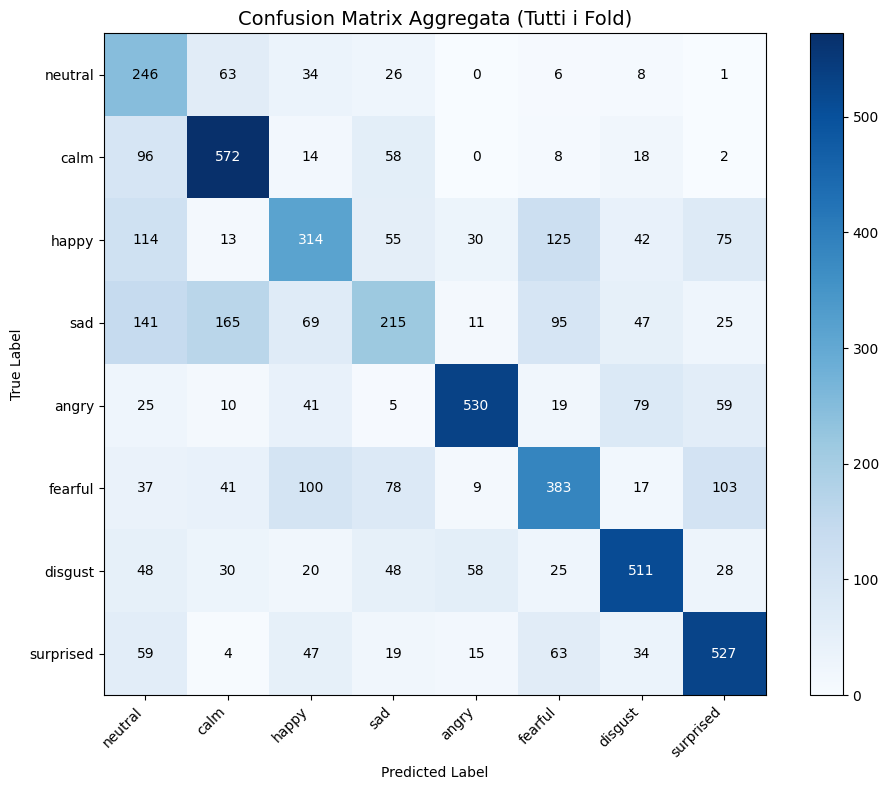


Classification Report Aggregato (Tutti i Fold):
              precision    recall  f1-score   support

     neutral     0.3211    0.6406    0.4278       384
        calm     0.6370    0.7448    0.6867       768
       happy     0.4914    0.4089    0.4463       768
         sad     0.4266    0.2799    0.3381       768
       angry     0.8116    0.6901    0.7460       768
     fearful     0.5290    0.4987    0.5134       768
     disgust     0.6759    0.6654    0.6706       768
   surprised     0.6427    0.6862    0.6637       768

    accuracy                         0.5726      5760
   macro avg     0.5669    0.5768    0.5616      5760
weighted avg     0.5833    0.5726    0.5705      5760


PERFORMANCE PER SPEAKER (quando usato come test set):
Speaker 05 (M): 0.4437
Speaker 11 (M): 0.4437
Speaker 17 (M): 0.4437
Speaker 23 (M): 0.4437
Speaker 03 (M): 0.5021
Speaker 09 (M): 0.5021
Speaker 15 (M): 0.5021
Speaker 21 (M): 0.5021
Speaker 01 (M): 0.5406
Speaker 07 (M): 0.5406
Speaker 13 (M):

In [ ]:
print(f"\n{'='*70}")
print(f"RISULTATI FINALI CROSS-VALIDATION ({N_FOLDS} FOLDS)")
print(f"{'='*70}\n")

# Estrai metriche
test_accs = [r['final_test_acc'] for r in fold_results]
val_accs = [r['best_val_acc'] for r in fold_results]

print("Risultati per fold:")
print(f"{'Fold':<6} {'Val Acc':<10} {'Test Acc':<10} {'Test Speakers'}")
print("-" * 70)
for r in fold_results:
    print(f"{r['fold']+1:<6} {r['best_val_acc']:<10.4f} {r['final_test_acc']:<10.4f} {r['test_speakers']}")

print("\n" + "=" * 70)
print(f"MEDIA ± STD:")
print(f"  Validation Acc: {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"  Test Acc:       {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")
print("=" * 70)

# %%
# STEP 6: VISUALIZZAZIONI

# 6A) Plot accuracy per fold
rows = 3
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 14))
axes = axes.flatten()

for idx, r in enumerate(fold_results):
    ax = axes[idx]
    epochs_range = range(1, len(r['val_acc_history']) + 1)
    ax.plot(epochs_range, r['val_acc_history'], label='Val', linewidth=2)
    ax.plot(epochs_range, r['test_acc_history'], label='Test', linewidth=2)
    ax.set_title(f"Fold {r['fold']+1} (Test Speakers: {r['test_speakers']})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.75, color='r', linestyle='--', alpha=0.5, label='Target 0.75')

# Ultimo subplot: confronto finale
ax = axes[-1]
x_pos = np.arange(N_FOLDS)
ax.bar(x_pos, test_accs, alpha=0.7, label='Test Acc')
ax.axhline(y=np.mean(test_accs), color='r', linestyle='--', 
           label=f'Mean: {np.mean(test_accs):.3f}')
ax.axhline(y=0.75, color='g', linestyle='--', label='Target: 0.75')
ax.set_xlabel('Fold')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'F{i+1}' for i in range(N_FOLDS)])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6B) Confusion Matrix aggregata (tutti i fold insieme)
all_y_true = []
all_y_pred = []
for r in fold_results:
    all_y_true.extend(r['y_true'])
    all_y_pred.extend(r['y_pred'])

cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix Aggregata (Tutti i Fold)', fontsize=14)
plt.colorbar()

tick_marks = np.arange(8)
target_names = [IDX2LABEL[i] for i in range(8)]
plt.xticks(tick_marks, target_names, rotation=45, ha='right')
plt.yticks(tick_marks, target_names)

# Aggiungi numeri nelle celle
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report Aggregato (Tutti i Fold):")
print(classification_report(all_y_true, all_y_pred, target_names=target_names, digits=4))

# %%
# STEP 7: ANALISI SPEAKER-SPECIFIC
# Vedi quali speaker sono più difficili da classificare

speaker_performance = {}
for r in fold_results:
    test_spk = r['test_speakers']
    test_acc = r['final_test_acc']
    for spk in test_spk:
        if spk not in speaker_performance:
            speaker_performance[spk] = []
        speaker_performance[spk].append(test_acc)

# Calcola media per speaker (se testato in più fold)
speaker_avg = {spk: np.mean(accs) for spk, accs in speaker_performance.items()}
speaker_sorted = sorted(speaker_avg.items(), key=lambda x: x[1])

print("\n" + "=" * 70)
print("PERFORMANCE PER SPEAKER (quando usato come test set):")
print("=" * 70)
for spk, avg_acc in speaker_sorted:
    gender = "F" if int(spk) % 2 == 0 else "M"
    print(f"Speaker {spk} ({gender}): {avg_acc:.4f}")

print("\nNOTA: Speaker con performance molto diverse potrebbero indicare")
print("      caratteristiche vocali particolarmente distintive o difficili.")

In [ ]:

# VISUAL ANALYSIS
# t-SNE on embeddings + Grad-CAM su spettrogrammi

import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from src.preprocessing.dataset import IDX2LABEL, parse_ravdess_filename

#t-SNE on embeddings 
@torch.no_grad()
def extract_crnn_embeddings(model, loader, device, return_paths=True):
    """
    Estrae embeddings dal CRNN SENZA modificare la classe.
    Qui definiamo "embedding" come il vettore dopo:
    CNN -> BiLSTM -> mean pooling temporale, prima del classifier.
    
    Ritorna:
      - emb: [N, D] numpy
      - y_true: [N] numpy
      - y_pred: [N] numpy
      - paths: lista file (opzionale)
    """
    model.eval()
    embs = []
    ys = []
    preds = []
    paths = []

    # Se il tuo Dataset non restituisce il path, lo ricaviamo via loader.dataset.filepaths
    # assumendo che loader NON shuffli (true per val/test nel tuo notebook)
    dataset_paths = getattr(loader.dataset, "filepaths", None)
    global_index = 0

    for batch in loader:
        x, y = batch
        x = x.to(device)

        # --- ricostruzione "forward fino all'embedding" basata sulla tua CRNN ---
        feat = model.cnn(x)                      # [B, C, M', T']
        b, c, m, t = feat.shape
        feat = feat.permute(0, 3, 1, 2).contiguous()  # [B, T', C, M']
        feat = feat.view(b, t, c * m)                 # [B, T', C*M']
        seq, _ = model.rnn(feat)                      # [B, T', 2H]
        emb = seq.mean(dim=1)                         # [B, 2H]  <-- embedding

        logits = model.classifier(emb)                # [B, n_classes]
        y_hat = logits.argmax(dim=1)

        embs.append(emb.detach().cpu())
        ys.append(y.detach().cpu())
        preds.append(y_hat.detach().cpu())

        if return_paths and dataset_paths is not None:
            bs = y.size(0)
            paths.extend(dataset_paths[global_index: global_index + bs])
            global_index += bs

    embs = torch.cat(embs, dim=0).numpy()
    ys = torch.cat(ys, dim=0).numpy()
    preds = torch.cat(preds, dim=0).numpy()

    return embs, ys, preds, paths


def tsne_project(embeddings, pca_dim=50, tsne_perplexity=30, tsne_lr="auto", seed=42):
    """
    PCA (opzionale) + t-SNE -> 2D
    """
    X = embeddings
    if pca_dim is not None and X.shape[1] > pca_dim:
        X = PCA(n_components=pca_dim, random_state=seed).fit_transform(X)

    tsne = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        learning_rate=tsne_lr,
        init="pca",
        random_state=seed
    )
    Z = tsne.fit_transform(X)
    return Z


def plot_tsne_by_label(Z, y_true, title="t-SNE (colored by true label)"):
    plt.figure(figsize=(10, 7))
    for k in np.unique(y_true):
        idx = (y_true == k)
        plt.scatter(Z[idx, 0], Z[idx, 1], s=18, alpha=0.75, label=IDX2LABEL[int(k)])
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.legend(markerscale=1.2, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_tsne_errors_and_speakers(Z, y_true, y_pred, paths, title="t-SNE (errors + speaker id)"):
    """
    Plot originale: evidenziamo errori e aggiungiamo speaker id.
    - corretto: marker 'o'
    - errato: marker 'x'
    Colore: emotion vera
    """
    correct = (y_true == y_pred)

    # Speaker/actor id dal filename (RAVDESS Actor_XX)
    speakers = []
    for fp in paths:
        actor = parse_ravdess_filename(fp)["actor"]
        speakers.append(actor)
    speakers = np.array(speakers)

    plt.figure(figsize=(10, 7))

    # Per non avere 24 legende, mettiamo speaker id come testo solo per alcuni punti (campionamento)
    # e ci concentriamo su errori vs corretti
    for k in np.unique(y_true):
        idx_k = (y_true == k)

        # corretti
        idx_ok = idx_k & correct
        plt.scatter(Z[idx_ok, 0], Z[idx_ok, 1], s=16, alpha=0.65, marker="o")

        # errati
        idx_bad = idx_k & (~correct)
        if idx_bad.any():
            plt.scatter(Z[idx_bad, 0], Z[idx_bad, 1], s=40, alpha=0.9, marker="x")

    # Aggiungi qualche speaker label sui punti sbagliati (molto utile per capire leakage)
    bad_idx = np.where(~correct)[0]
    for i in bad_idx[:30]:  # limita per non “sporcare” il grafico
        plt.text(Z[i, 0], Z[i, 1], speakers[i], fontsize=8, alpha=0.85)

    plt.title(title + "  (x = misclassified; text = speaker id on some errors)")
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.tight_layout()
    plt.show()

#Grad-CAM on spectrograms
def find_last_conv2d(module: nn.Module):
    """
    Trova automaticamente l'ultimo nn.Conv2d dentro un modello (o sotto-moduli).
    Così se cambi architettura, spesso non devi cambiare nulla.
    """
    last = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    if last is None:
        raise RuntimeError("Nessun nn.Conv2d trovato: non posso fare Grad-CAM.")
    return last


class GradCAM:
    """
    Grad-CAM generico:
    - hook su ultimo Conv2d (o quello che passi tu)
    - produce heatmap (H x W) allineata allo spettrogramma input
    """
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_a = target_layer.register_forward_hook(self._forward_hook)
        self.hook_g = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out  # [B, C, H, W]

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]  # [B, C, H, W]

    def close(self):
        self.hook_a.remove()
        self.hook_g.remove()

    def __call__(self, x, class_idx=None):
        import torch.nn as nn
        import torch.nn.functional as F

        # salva stato originale
        was_training = self.model.training

        # serve per far funzionare backward su cuDNN LSTM
        self.model.train()

        # disattiva dropout per mappe stabili
        for m in self.model.modules():
            if isinstance(m, nn.Dropout):
                m.eval()

        self.model.zero_grad(set_to_none=True)

        logits = self.model(x)  # [1, n_classes]
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        # attivazioni e gradienti dal layer target
        A = self.activations          # [1, C, H, W]
        G = self.gradients            # [1, C, H, W]
        if A is None or G is None:
            raise RuntimeError("Hooks Grad-CAM non hanno catturato activations/gradients. Controlla target_layer.")

        # pesi: global average pooling dei gradienti
        weights = G.mean(dim=(2, 3), keepdim=True)       # [1, C, 1, 1]

        # somma pesata delle attivazioni
        cam = (weights * A).sum(dim=1, keepdim=True)     # [1, 1, H, W]
        cam = F.relu(cam)

        # normalizzazione
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-9)

        # upsample alla size dello spettrogramma di input
        cam_up = F.interpolate(
            cam,
            size=(x.shape[2], x.shape[3]),
            mode="bilinear",
            align_corners=False
        )  # [1, 1, n_mels, T]

        # ripristina stato originale
        if not was_training:
            self.model.eval()

        return cam_up.detach().cpu().squeeze(0).squeeze(0), class_idx, logits.detach().cpu()



def show_gradcam_on_spectrogram(spec, cam, title="", true_label=None, pred_label=None):
    """
    spec: [1, n_mels, T] tensor (cpu o gpu)
    cam:  [n_mels, T] tensor cpu (da GradCAM)
    """
    spec = spec.detach().cpu().squeeze(0)  # [n_mels, T]

    plt.figure(figsize=(12, 4))
    plt.imshow(spec, aspect="auto", origin="lower")
    plt.imshow(cam, aspect="auto", origin="lower", alpha=0.45)  # overlay
    t = title
    if true_label is not None and pred_label is not None:
        t += f" | true={true_label} pred={pred_label}"
    plt.title(t)
    plt.xlabel("time")
    plt.ylabel("mel bins")
    plt.tight_layout()
    plt.show()


def gradcam_demo(model, loader, device, n_examples=10, seed=42, class_mode="pred"):
    """
    Seleziona n_examples campioni casuali e mostra Grad-CAM.
    class_mode:
      - "pred": spiega la classe predetta
      - "true": spiega la classe vera
    """
    rng = np.random.RandomState(seed)
    idxs = rng.choice(len(loader.dataset), size=min(n_examples, len(loader.dataset)), replace=False)

    target_layer = find_last_conv2d(model)
    cam_engine = GradCAM(model, target_layer)

    model.eval()
    for i in idxs:
        spec, y = loader.dataset[i]  # spec: [1, n_mels, T]
        x = spec.unsqueeze(0).to(device)  # [1,1,n_mels,T]
        y = int(y.item())

        if class_mode == "true":
            cam, cidx, logits = cam_engine(x, class_idx=y)
        else:
            cam, cidx, logits = cam_engine(x, class_idx=None)

        pred = int(logits.argmax(dim=1).item())
        show_gradcam_on_spectrogram(
            spec,
            cam,
            title="C) Grad-CAM on log-mel spectrogram",
            true_label=IDX2LABEL[y],
            pred_label=IDX2LABEL[pred]
        )
    cam_engine.close()


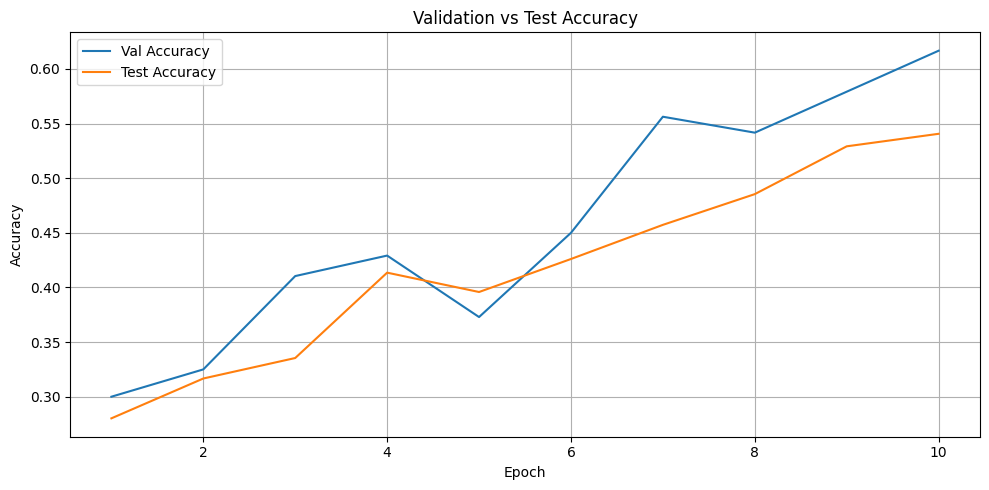


Best val acc: 0.6166666666666667
TEST (best checkpoint) | loss 1.3122 acc 0.5406

VISUAL ANALYSIS – FOLD 1


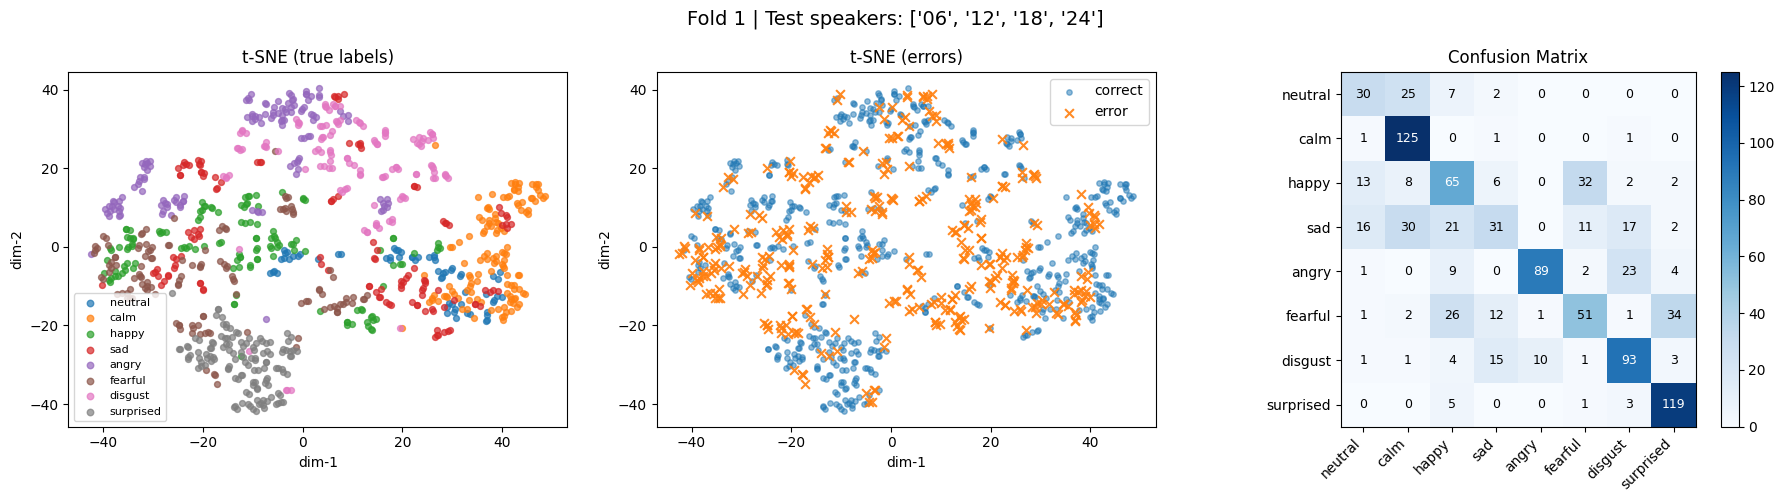

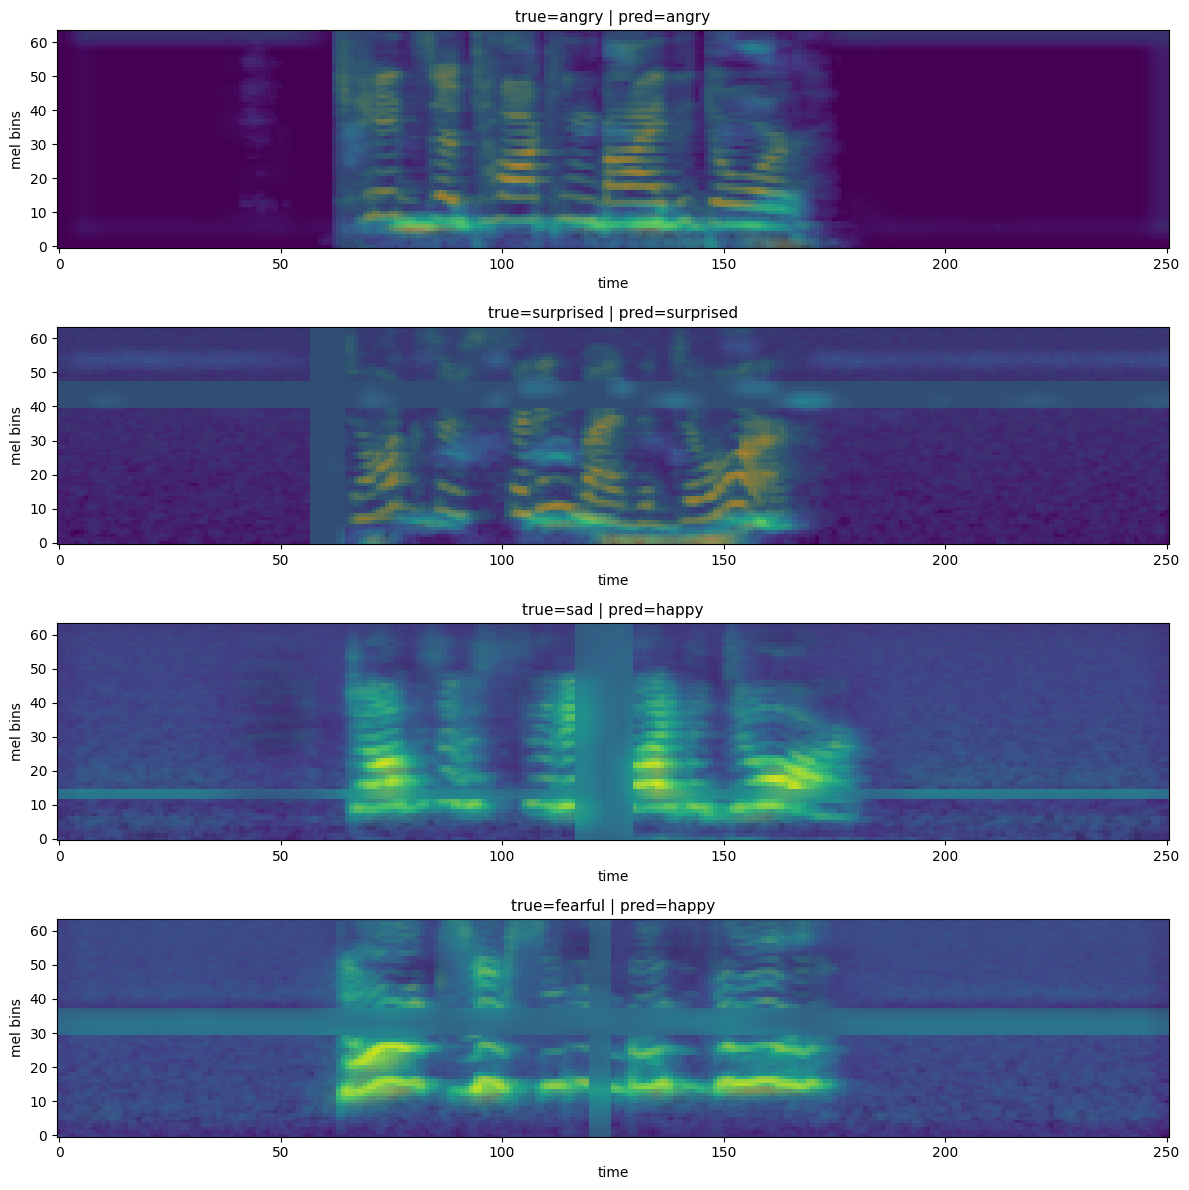


Classification report:
              precision    recall  f1-score   support

     neutral     0.4762    0.4688    0.4724        64
        calm     0.6545    0.9766    0.7837       128
       happy     0.4745    0.5078    0.4906       128
         sad     0.4627    0.2422    0.3179       128
       angry     0.8900    0.6953    0.7807       128
     fearful     0.5204    0.3984    0.4513       128
     disgust     0.6643    0.7266    0.6940       128
   surprised     0.7256    0.9297    0.8151       128

    accuracy                         0.6281       960
   macro avg     0.6085    0.6182    0.6007       960
weighted avg     0.6173    0.6281    0.6093       960


VISUAL ANALYSIS – FOLD 2


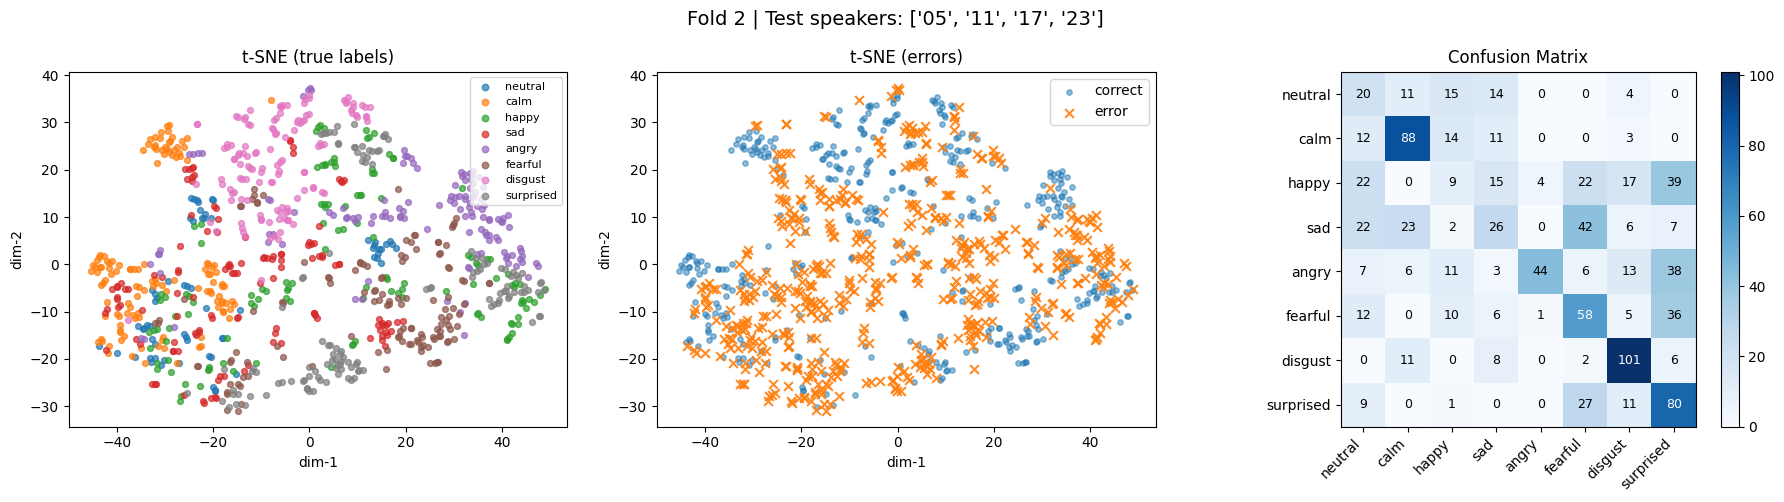

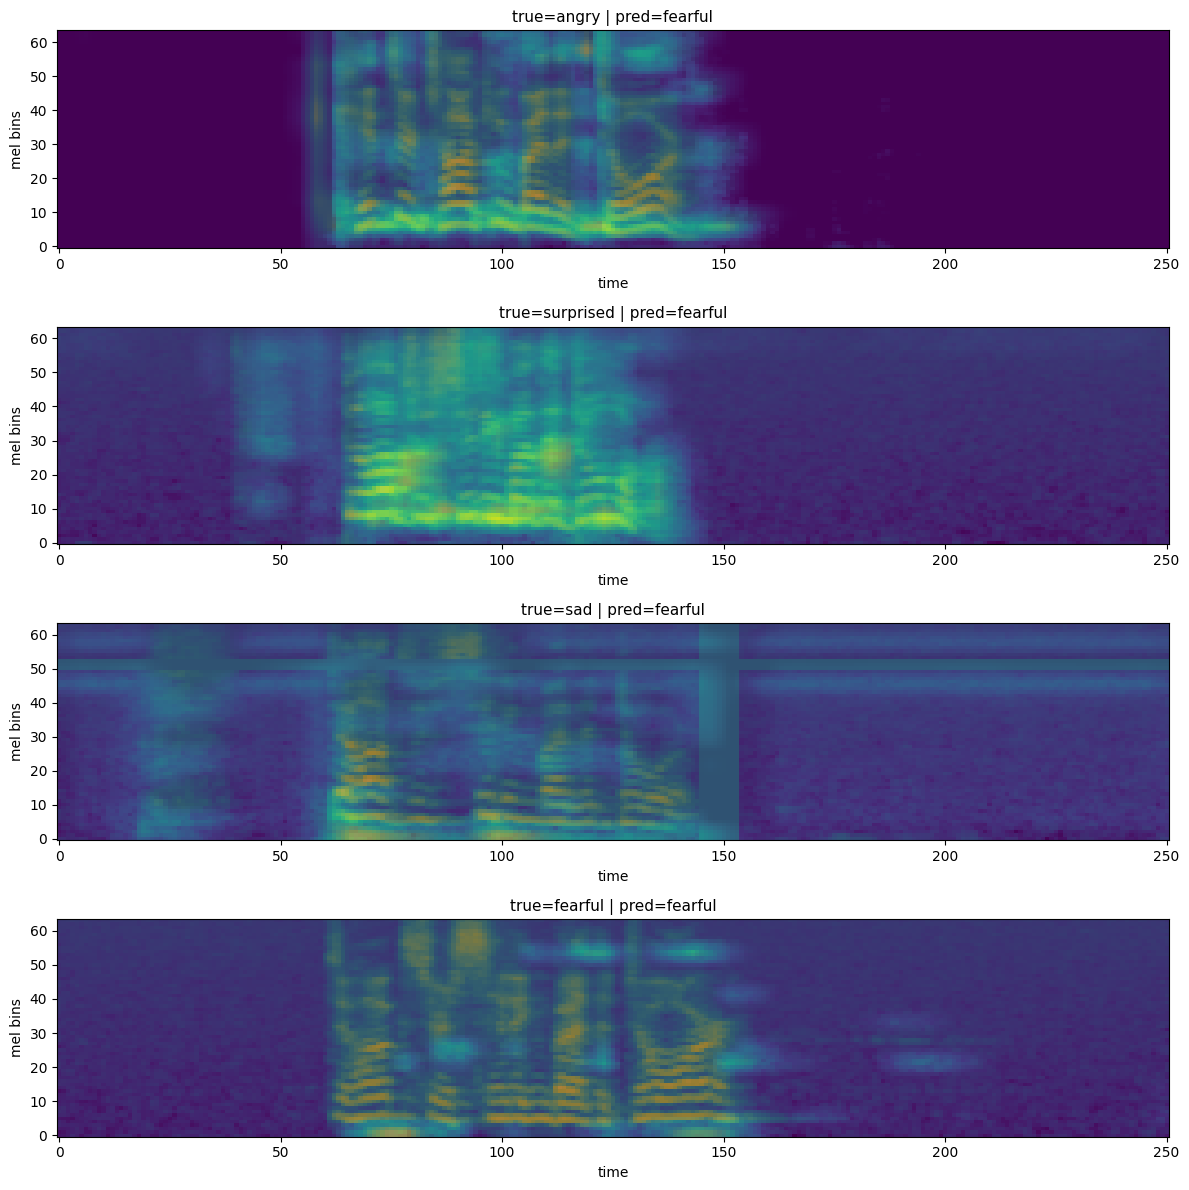


Classification report:
              precision    recall  f1-score   support

     neutral     0.1923    0.3125    0.2381        64
        calm     0.6331    0.6875    0.6592       128
       happy     0.1452    0.0703    0.0947       128
         sad     0.3133    0.2031    0.2464       128
       angry     0.8980    0.3438    0.4972       128
     fearful     0.3694    0.4531    0.4070       128
     disgust     0.6312    0.7891    0.7014       128
   surprised     0.3883    0.6250    0.4790       128

    accuracy                         0.4437       960
   macro avg     0.4464    0.4355    0.4154       960
weighted avg     0.4633    0.4437    0.4272       960


VISUAL ANALYSIS – FOLD 3


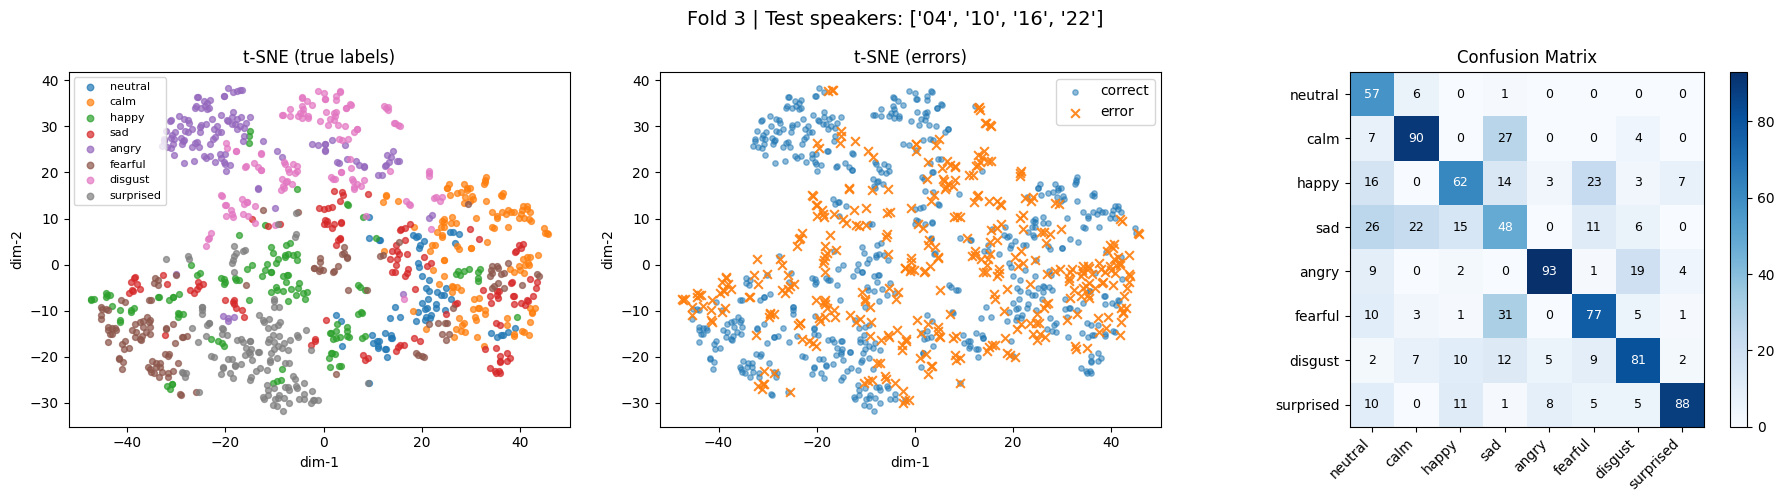

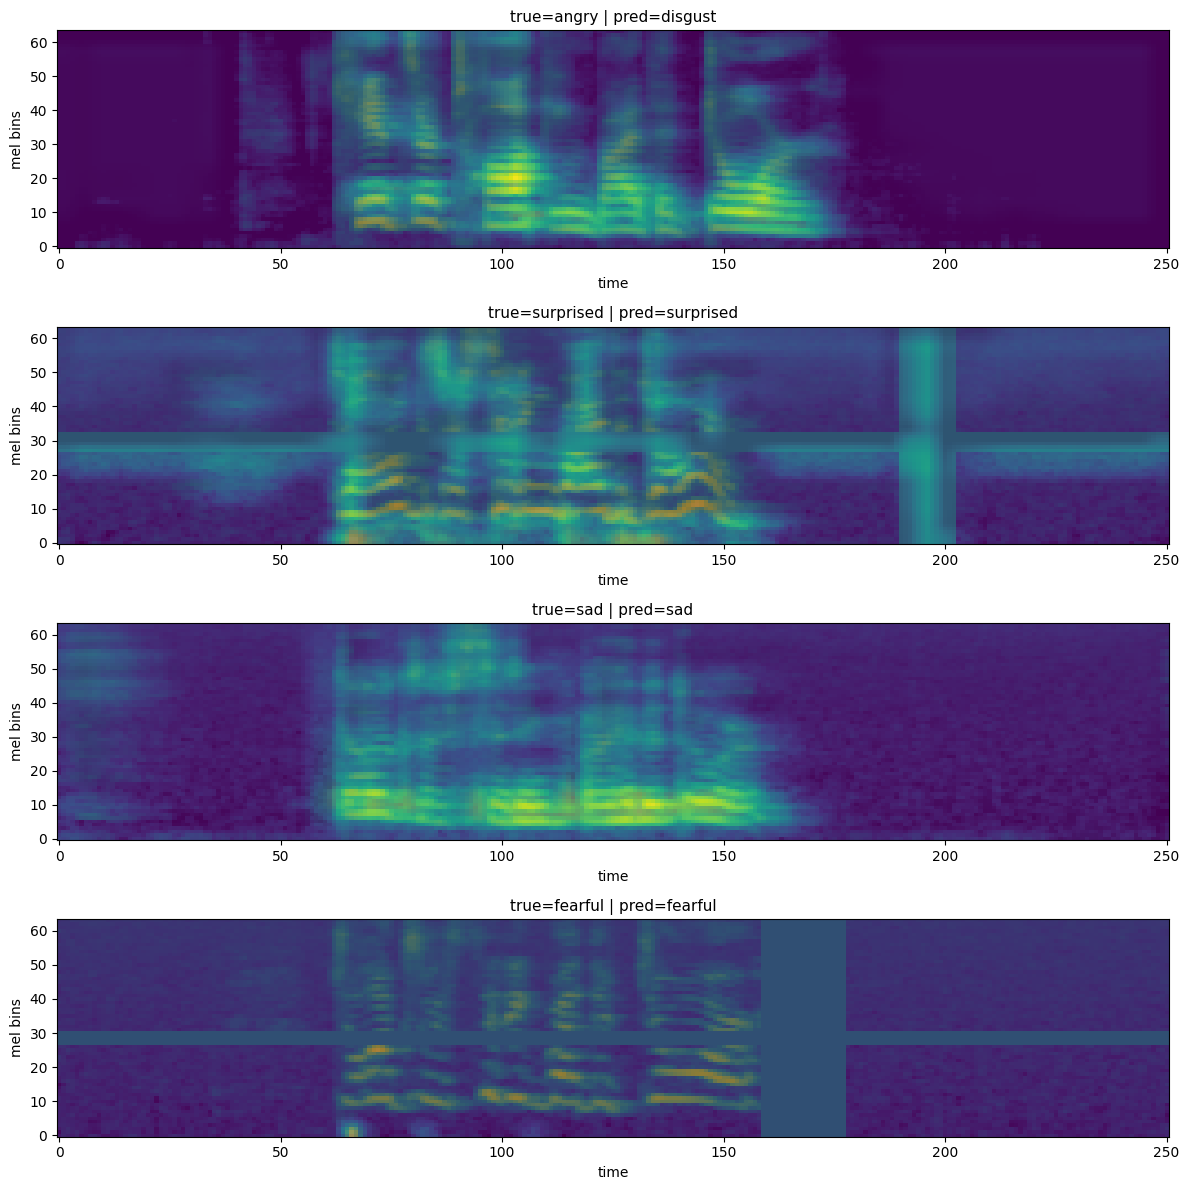


Classification report:
              precision    recall  f1-score   support

     neutral     0.4161    0.8906    0.5672        64
        calm     0.7031    0.7031    0.7031       128
       happy     0.6139    0.4844    0.5415       128
         sad     0.3582    0.3750    0.3664       128
       angry     0.8532    0.7266    0.7848       128
     fearful     0.6111    0.6016    0.6063       128
     disgust     0.6585    0.6328    0.6454       128
   surprised     0.8627    0.6875    0.7652       128

    accuracy                         0.6208       960
   macro avg     0.6346    0.6377    0.6225       960
weighted avg     0.6492    0.6208    0.6262       960


VISUAL ANALYSIS – FOLD 4


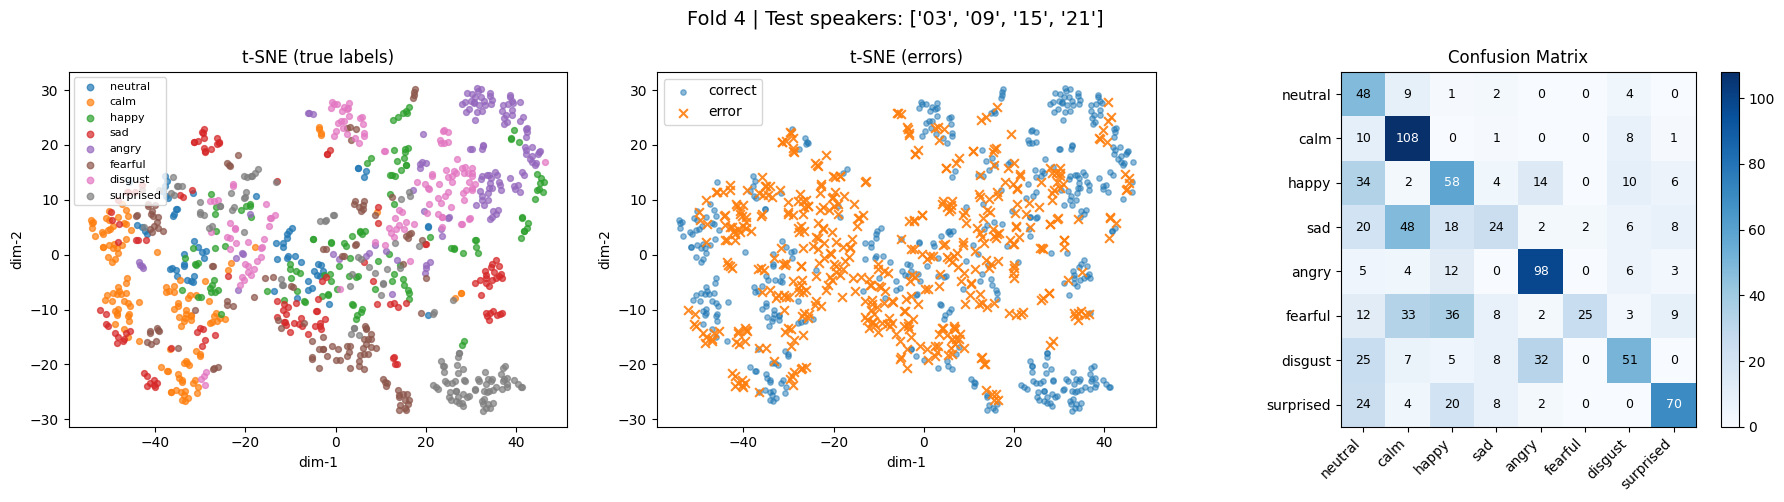

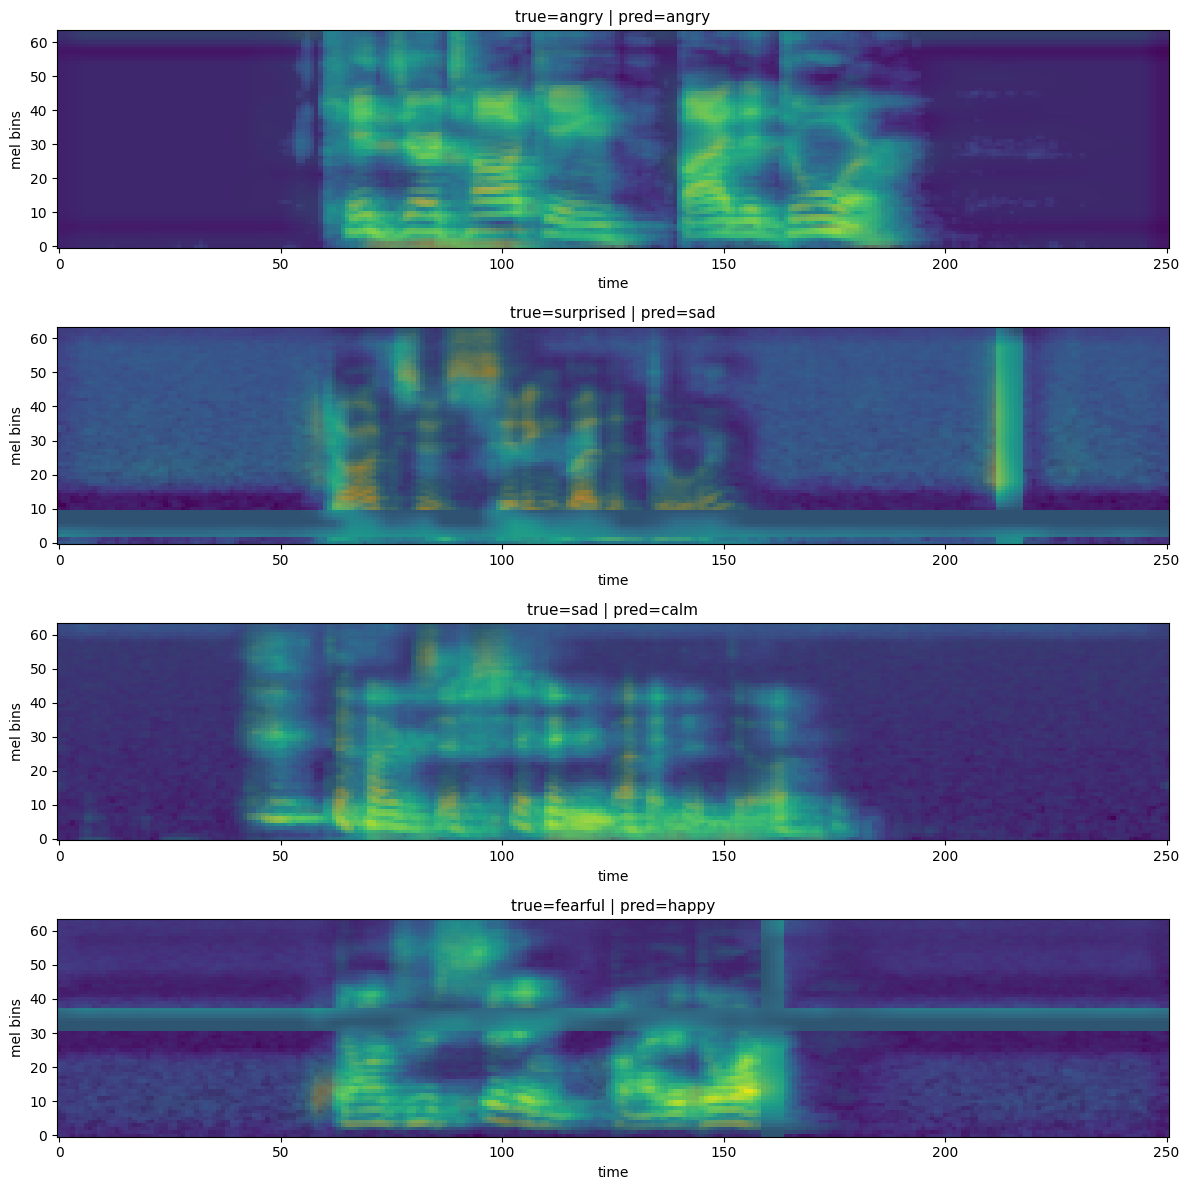


Classification report:
              precision    recall  f1-score   support

     neutral     0.2697    0.7500    0.3967        64
        calm     0.5023    0.8438    0.6297       128
       happy     0.3867    0.4531    0.4173       128
         sad     0.4364    0.1875    0.2623       128
       angry     0.6533    0.7656    0.7050       128
     fearful     0.9259    0.1953    0.3226       128
     disgust     0.5795    0.3984    0.4722       128
   surprised     0.7216    0.5469    0.6222       128

    accuracy                         0.5021       960
   macro avg     0.5594    0.5176    0.4785       960
weighted avg     0.5788    0.5021    0.4840       960


VISUAL ANALYSIS – FOLD 5


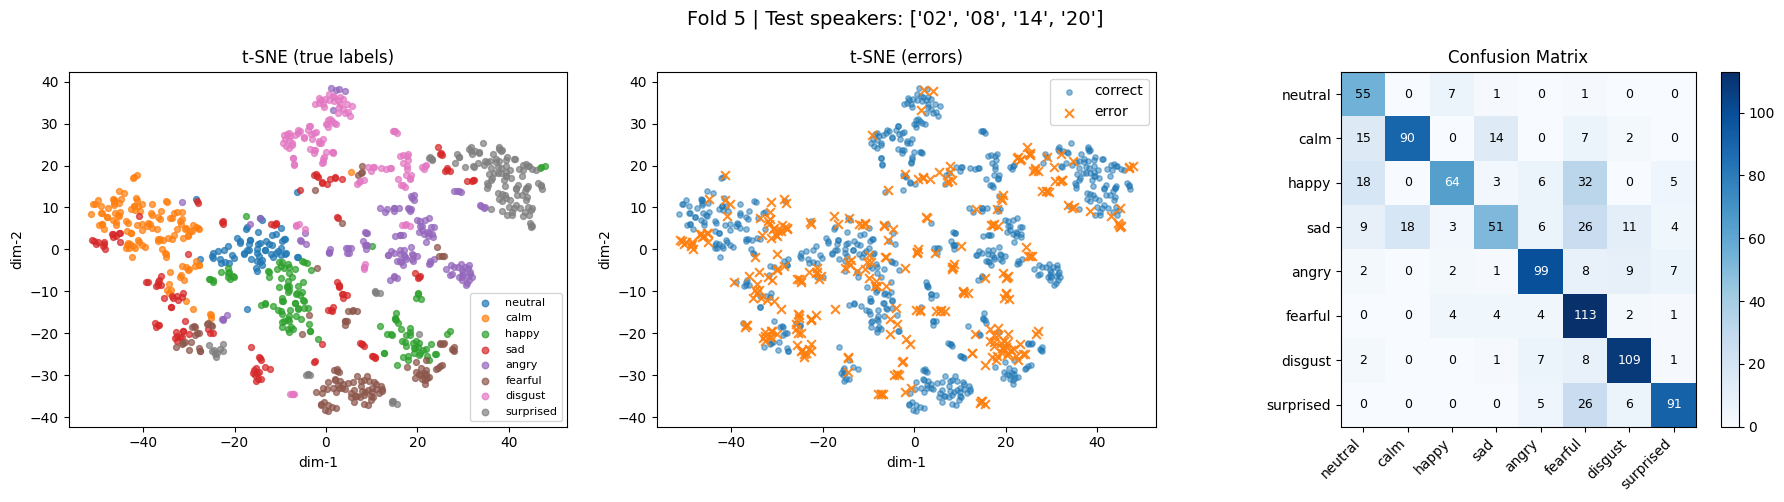

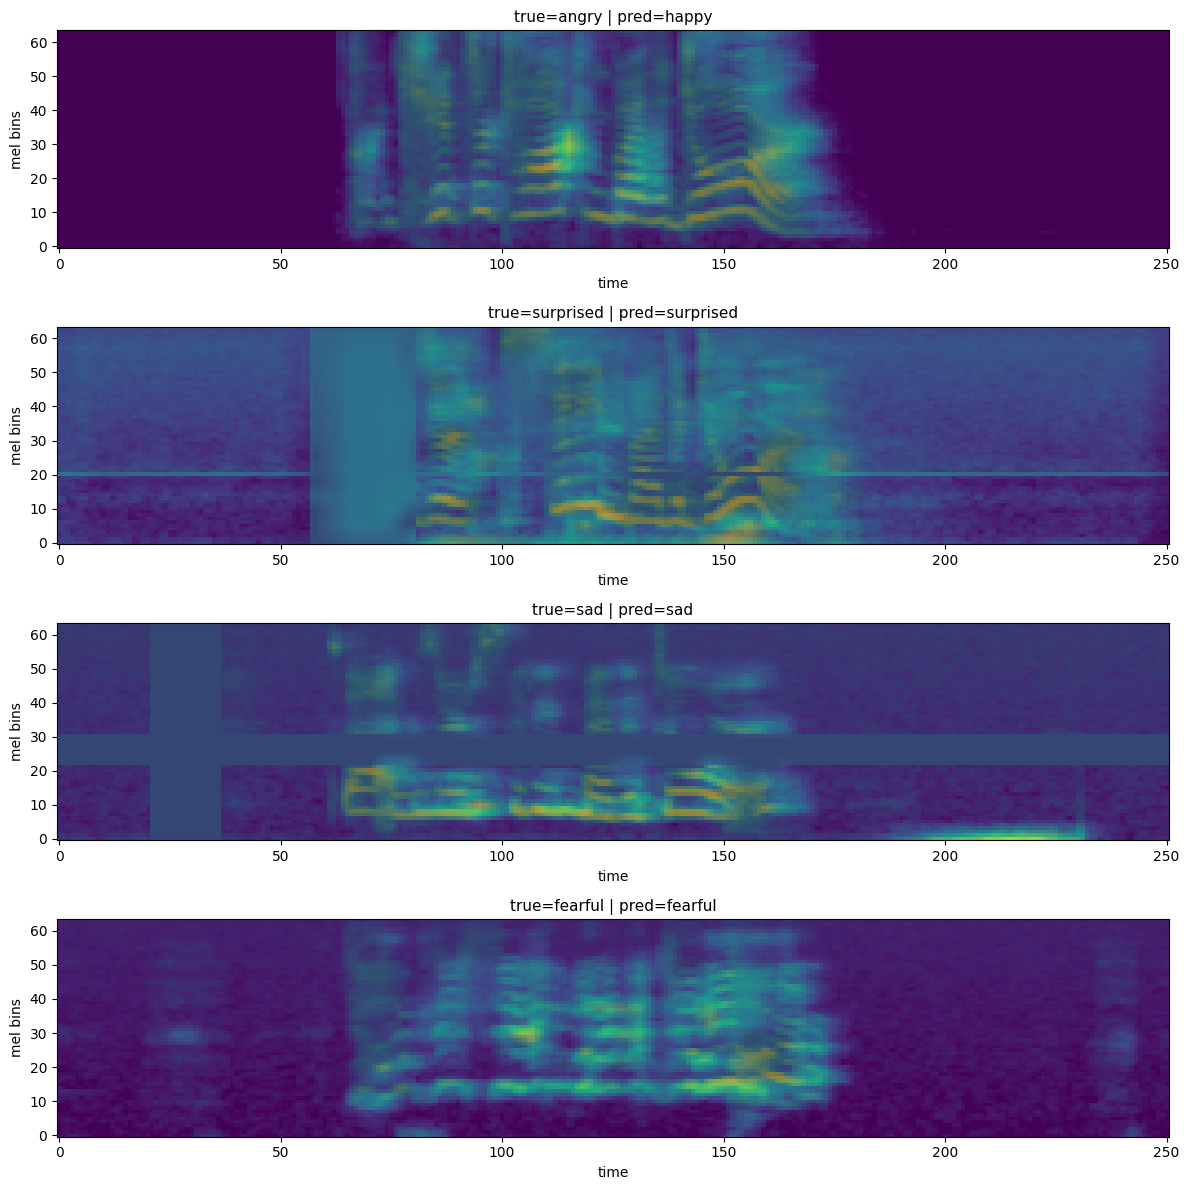


Classification report:
              precision    recall  f1-score   support

     neutral     0.5446    0.8594    0.6667        64
        calm     0.8333    0.7031    0.7627       128
       happy     0.8000    0.5000    0.6154       128
         sad     0.6800    0.3984    0.5025       128
       angry     0.7795    0.7734    0.7765       128
     fearful     0.5113    0.8828    0.6476       128
     disgust     0.7842    0.8516    0.8165       128
   surprised     0.8349    0.7109    0.7679       128

    accuracy                         0.7000       960
   macro avg     0.7210    0.7100    0.6945       960
weighted avg     0.7327    0.7000    0.6963       960


VISUAL ANALYSIS – FOLD 6


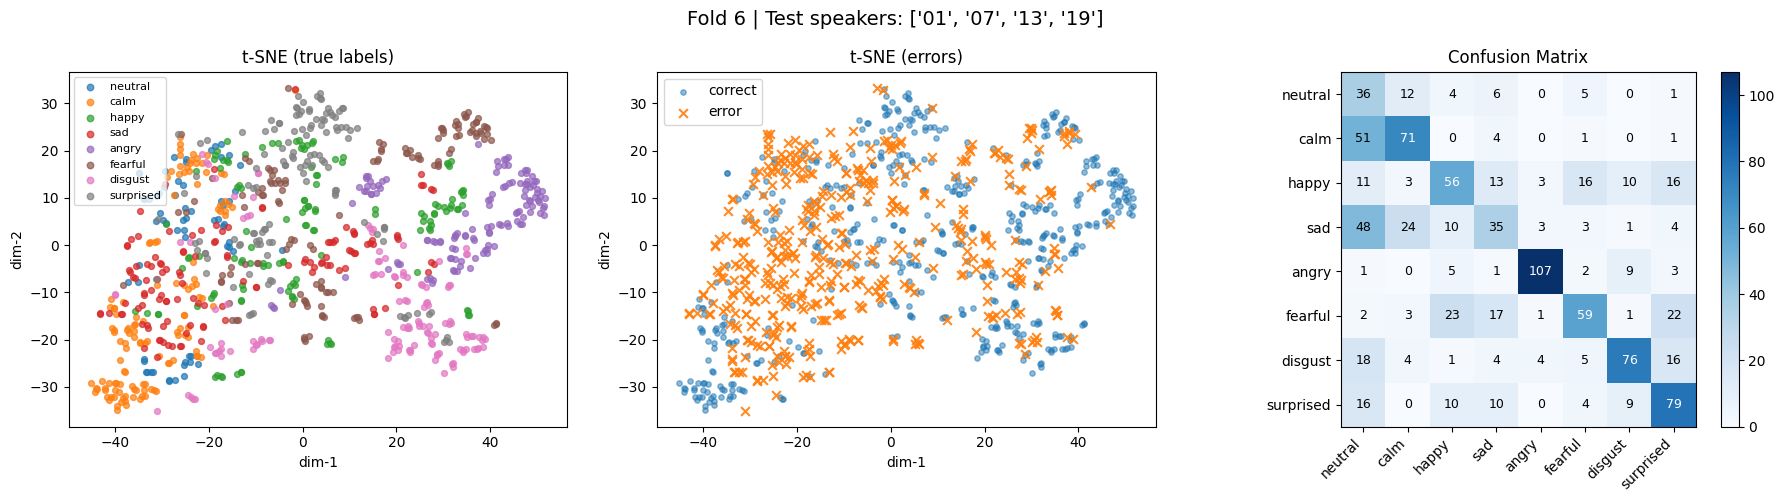

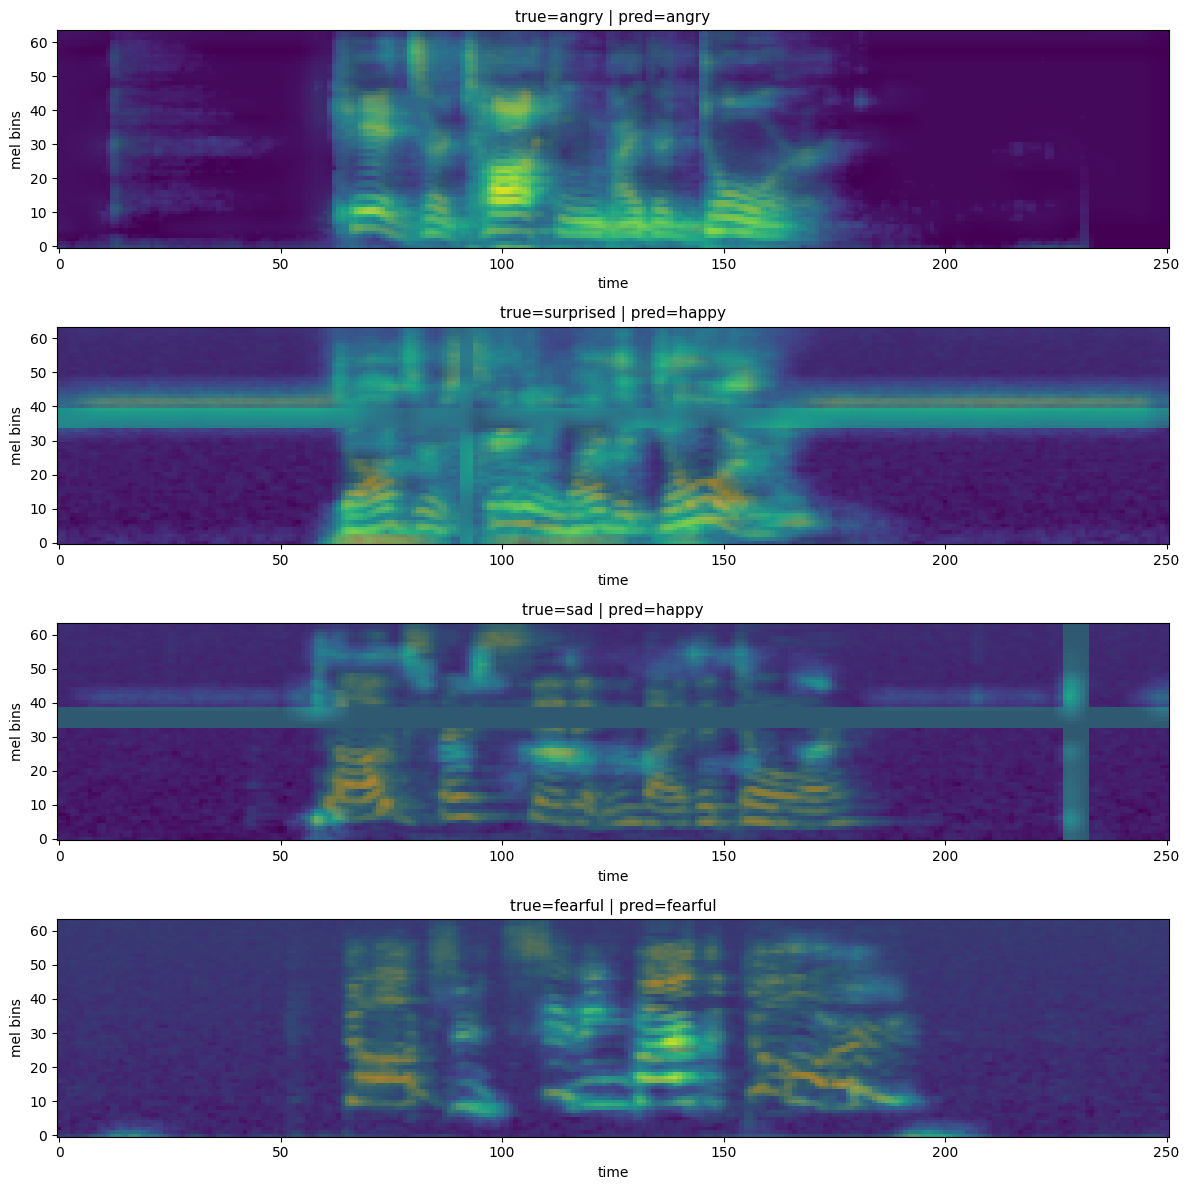


Classification report:
              precision    recall  f1-score   support

     neutral     0.1967    0.5625    0.2915        64
        calm     0.6068    0.5547    0.5796       128
       happy     0.5138    0.4375    0.4726       128
         sad     0.3889    0.2734    0.3211       128
       angry     0.9068    0.8359    0.8699       128
     fearful     0.6211    0.4609    0.5291       128
     disgust     0.7170    0.5938    0.6496       128
   surprised     0.5563    0.6172    0.5852       128

    accuracy                         0.5406       960
   macro avg     0.5634    0.5420    0.5373       960
weighted avg     0.5879    0.5406    0.5537       960



In [ ]:

# Grafico accuracy train vs val
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, val_acc_hist, label="Val Accuracy")
plt.plot(epochs_range, test_acc_hist, label="Test Accuracy")
plt.title("Validation vs Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 7) test finale con best checkpoint
print("\nBest val acc:", best_val_acc)
model.load_state_dict(torch.load(best_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, device)
print(f"TEST (best checkpoint) | loss {test_loss:.4f} acc {test_acc:.4f}")


def gradcam_summary(model, loader, device, n_examples=4, seed=42):
    """
    Mostra Grad-CAM su pochi esempi in una figura compatta.
    """
    rng = np.random.RandomState(seed)
    idxs = rng.choice(
        len(loader.dataset),
        size=min(n_examples, len(loader.dataset)),
        replace=False
    )

    target_layer = find_last_conv2d(model)
    cam_engine = GradCAM(model, target_layer)

    fig, axes = plt.subplots(len(idxs), 1, figsize=(12, 3 * len(idxs)))
    if len(idxs) == 1:
        axes = [axes]

    model.eval()
    for ax, i in zip(axes, idxs):
        spec, y = loader.dataset[i]
        x = spec.unsqueeze(0).to(device)
        y = int(y.item())

        cam, _, logits = cam_engine(x, class_idx=None)
        pred = int(logits.argmax(dim=1).item())

        spec_np = spec.squeeze(0).cpu().numpy()
        cam_np = cam.numpy()

        ax.imshow(spec_np, aspect="auto", origin="lower")
        ax.imshow(cam_np, aspect="auto", origin="lower", alpha=0.45)
        ax.set_title(
            f"true={IDX2LABEL[y]} | pred={IDX2LABEL[pred]}",
            fontsize=11
        )
        ax.set_xlabel("time")
        ax.set_ylabel("mel bins")

    plt.tight_layout()
    plt.show()
    cam_engine.close()

def plot_fold_summary(Z, y_true, y_pred, fold_idx, test_speakers):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # t-SNE – true labels
    ax = axes[0]
    for k in np.unique(y_true):
        idx = (y_true == k)
        ax.scatter(
            Z[idx, 0], Z[idx, 1],
            s=18, alpha=0.7,
            label=IDX2LABEL[int(k)]
        )
    ax.set_title("t-SNE (true labels)")
    ax.set_xlabel("dim-1")
    ax.set_ylabel("dim-2")
    ax.legend(fontsize=8, markerscale=1.1)

    # t-SNE – correct vs error
    ax = axes[1]
    correct = (y_true == y_pred)
    ax.scatter(
        Z[correct, 0], Z[correct, 1],
        s=15, alpha=0.5, label="correct"
    )
    ax.scatter(
        Z[~correct, 0], Z[~correct, 1],
        s=40, alpha=0.9, marker="x", label="error"
    )
    ax.set_title("t-SNE (errors)")
    ax.set_xlabel("dim-1")
    ax.set_ylabel("dim-2")
    ax.legend()

    # Confusion Matrix
    ax = axes[2]
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Confusion Matrix")

    tick_marks = np.arange(len(IDX2LABEL))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels([IDX2LABEL[i] for i in tick_marks], rotation=45, ha="right")
    ax.set_yticklabels([IDX2LABEL[i] for i in tick_marks])

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=9
            )

    fig.colorbar(im, ax=ax, fraction=0.046)

    # Titolo globale
    fig.suptitle(
        f"Fold {fold_idx + 1} | Test speakers: {test_speakers}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# LOOP SU TUTTI I FOLD
gkf = GroupKFold(n_splits=N_FOLDS)
splits = list(gkf.split(all_files, labels, groups=actors))

for fold_idx in range(N_FOLDS):
    print("\n" + "=" * 80)
    print(f"VISUAL ANALYSIS – FOLD {fold_idx + 1}")
    print("=" * 80)

    # Test loader del fold
    _, test_idx = splits[fold_idx]
    test_files = [all_files[i] for i in test_idx]
    test_speakers = sorted({actors[i] for i in test_idx})

    test_ds = PrecomputedDataset(PRECOMPUTED_DIR, test_speakers)
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    # Modello del fold
    model = CRNN(n_classes=8, n_mels=64).to(device)
    model.load_state_dict(
        torch.load(f"best_fold_{fold_idx+1}.pt", map_location=device)
    )
    model.eval()

    # Embeddings + t-SNE
    emb, y_true_e, y_pred_e, _ = extract_crnn_embeddings(
        model, test_loader, device, return_paths=False
    )

    Z = tsne_project(
        emb,
        pca_dim=50,
        tsne_perplexity=30,
        seed=42
    )

    # Figura compatta
    plot_fold_summary(
        Z,
        y_true_e,
        y_pred_e,
        fold_idx,
        test_speakers
    )

    # gradcam

    gradcam_summary(
        model,
        test_loader,
        device,
        n_examples=4,   # 3–4 è perfetto
        seed=42
    )

    # Report testuale 
    print("\nClassification report:")
    target_names = [IDX2LABEL[i] for i in range(8)]
    print(classification_report(
        y_true_e, y_pred_e,
        target_names=target_names,
        digits=4
    ))


